# Feature Engineering 03: Directional Conditional Dependency

This notebook evaluates a small, declared set of directional hypotheses of the form `Gene A context -> Gene B dependency`. It does not test every gene pair, train a model, rank cell lines, or calculate a probability.

Conditional dependency asks whether a measurable state of Gene A makes cells more vulnerable to knockout of Gene B. Direction matters: `ARID1A -> EZH2` is a different biological question from `EZH2 -> ARID1A`.

## Biological Question and Feature Contract

For each pre-specified hypothesis, is Gene-B CRISPR gene effect more negative in models carrying the declared Gene-A context than in an explicit reference group?

The primary feature is `dependency_shift_adjusted`:

`median(reference lineage-adjusted effect) - median(context lineage-adjusted effect)`

Because more negative CRISPR gene effect means stronger dependency, a **positive** shift supports the directional hypothesis. Mutation, copy-number loss, copy-number gain, and RNA-high contexts remain separate rows with separate definitions.

**Grain:** one row per declared directional hypothesis and context definition.

## Research Basis

- [ISLE](https://www.nature.com/articles/s41467-018-04647-1) and [MiSL](https://www.nature.com/articles/ncomms15580) support evaluating synthetic-lethal relationships in a specific molecular and disease context rather than as universal pair properties.
- [Farmer et al.](https://pubmed.ncbi.nlm.nih.gov/15829967/) provides the classic BRCA-PARP synthetic-lethality example.
- [Bitler et al.](https://www.nature.com/articles/nm.3799) provides biological support for the ARID1A-EZH2 hypothesis.
- Released [Chronos](https://pubmed.ncbi.nlm.nih.gov/34930405/) gene-effect values are used for the target dependency measurement.

These papers motivate hypotheses and calculations. They are not used as labels proving that the current cell-line result is correct.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, rankdata

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 25
MIN_LINEAGE_MODELS = 15
MIN_CONTEXT_MODELS = 10
MIN_REFERENCE_MODELS = 10
MIN_TOTAL_MODELS = 30
BOOTSTRAP_REPLICATES = 500

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        marker = candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv'
        if marker.exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
RAW = DATA / 'raw'
DERIVED = DATA / 'derived'
ARCHITECTURE = DATA / 'architecture'
OUTPUT_DIR = ARCHITECTURE / 'feature_engineering'
OUTPUT_DIR.mkdir(exist_ok=True)

PATHS = {
    'model_master': ARCHITECTURE / 'model_master.csv',
    'gene_master': ARCHITECTURE / 'gene_master.csv',
    'crispr_context': ARCHITECTURE / 'model_crispr_context.csv',
    'gene_effect': RAW / 'CRISPRGeneEffect.csv',
    'gene_dependency': RAW / 'CRISPRGeneDependency.csv',
    'mutations': DERIVED / 'mutations_default_dna_gene_summary.csv',
    'copy_number': RAW / 'OmicsAbsoluteCNGene.csv',
    'expression': DERIVED / 'expression_default_rna_model.csv',
    'features': OUTPUT_DIR / 'directional_conditional_dependency_features.csv',
    'manifest': OUTPUT_DIR / 'directional_conditional_dependency_manifest.json',
}

master = pd.read_csv(PATHS['model_master'], low_memory=False)
genes = pd.read_csv(PATHS['gene_master'], low_memory=False)
crispr_context = pd.read_csv(PATHS['crispr_context'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
assert master['model_id'].is_unique
assert genes['symbol'].is_unique
assert crispr_context['model_id'].is_unique
print(f'Model master: {len(master):,} models')
print(f'Gene-level mutation summary: {len(mutations):,} records')

Model master: 2,105 models
Gene-level mutation summary: 646,941 records


## 1. Declare Directional Hypotheses

Each row states the mechanism before looking at the result. The panel includes known biological examples, plausible pathway relationships, and warning cases. Adding a new hypothesis requires a context definition and biological reason.

In [2]:
hypotheses = pd.DataFrame([
    ('ARID1A', 'EZH2', 'mutation', 'Chromatin-regulation synthetic-lethality hypothesis'),
    ('BRCA1', 'PARP1', 'mutation', 'DNA-repair synthetic-lethality hypothesis'),
    ('BRCA2', 'PARP1', 'mutation', 'DNA-repair synthetic-lethality hypothesis'),
    ('SMARCA4', 'SMARCA2', 'mutation', 'SWI/SNF paralog vulnerability hypothesis'),
    ('STAG2', 'STAG1', 'mutation', 'Cohesin paralog vulnerability hypothesis'),
    ('KRAS', 'RAF1', 'mutation', 'Oncogenic RAS signalling-context hypothesis'),
    ('BRAF', 'MAP2K1', 'mutation', 'Oncogenic MAPK signalling-context hypothesis'),
    ('TP53', 'MDM2', 'mutation', 'Mechanism warning: MDM2 dependence may require intact TP53'),
    ('MTAP', 'PRMT5', 'copy_number_loss', 'MTAP-deletion metabolic vulnerability hypothesis'),
    ('MTAP', 'MAT2A', 'copy_number_loss', 'MTAP-deletion metabolic vulnerability hypothesis'),
    ('SMARCA4', 'SMARCA2', 'copy_number_loss', 'SWI/SNF loss-context hypothesis'),
    ('STAG2', 'STAG1', 'copy_number_loss', 'Cohesin loss-context hypothesis'),
    ('ERBB2', 'ERBB3', 'copy_number_gain', 'ERBB2-amplified signalling-context hypothesis'),
    ('MYC', 'MAX', 'copy_number_gain', 'MYC-amplified transcriptional-context hypothesis'),
    ('ERBB2', 'ERBB3', 'rna_high', 'ERBB2-high signalling-context hypothesis'),
    ('MYC', 'MAX', 'rna_high', 'MYC-high transcriptional-context hypothesis'),
], columns=['context_gene', 'target_gene', 'context_type', 'biological_reason'])

hypotheses['directional_pair_id'] = hypotheses['context_gene'] + ' -> ' + hypotheses['target_gene']
hypotheses['hypothesis_id'] = hypotheses['directional_pair_id'] + ' | ' + hypotheses['context_type']
assert hypotheses['hypothesis_id'].is_unique
display(hypotheses)

,context_gene,target_gene,context_type,biological_reason,directional_pair_id,hypothesis_id
0,ARID1A,EZH2,mutation,Chromatin-regulation synthetic-lethality hypot...,ARID1A -> EZH2,ARID1A -> EZH2 | mutation
1,BRCA1,PARP1,mutation,DNA-repair synthetic-lethality hypothesis,BRCA1 -> PARP1,BRCA1 -> PARP1 | mutation
2,BRCA2,PARP1,mutation,DNA-repair synthetic-lethality hypothesis,BRCA2 -> PARP1,BRCA2 -> PARP1 | mutation
3,SMARCA4,SMARCA2,mutation,SWI/SNF paralog vulnerability hypothesis,SMARCA4 -> SMARCA2,SMARCA4 -> SMARCA2 | mutation
4,STAG2,STAG1,mutation,Cohesin paralog vulnerability hypothesis,STAG2 -> STAG1,STAG2 -> STAG1 | mutation
5,KRAS,RAF1,mutation,Oncogenic RAS signalling-context hypothesis,KRAS -> RAF1,KRAS -> RAF1 | mutation
6,BRAF,MAP2K1,mutation,Oncogenic MAPK signalling-context hypothesis,BRAF -> MAP2K1,BRAF -> MAP2K1 | mutation
7,TP53,MDM2,mutation,Mechanism warning: MDM2 dependence may require...,TP53 -> MDM2,TP53 -> MDM2 | mutation
8,MTAP,PRMT5,copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,MTAP -> PRMT5,MTAP -> PRMT5 | copy_number_loss
9,MTAP,MAT2A,copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,MTAP -> MAT2A,MTAP -> MAT2A | copy_number_loss


## Column Dictionary

| Feature | Simple meaning | Project role |
|---|---|---|
| `directional_pair_id` | Ordered hypothesis `Gene A -> Gene B`. | Preserves biological direction. |
| `context_type` | Mutation, absolute-CN loss, absolute-CN gain, or RNA high. | Keeps different mechanisms separate. |
| `context_definition` | Exact rule assigning context and reference models. | Makes the feature reproducible. |
| `dependency_shift_adjusted` | Reference median minus context median after lineage adjustment. | Primary feature; positive means stronger Gene-B dependency in context models. |
| `dependency_rank_effect_adjusted` | Rank-based effect with positive direction aligned to stronger context dependency. | Robust companion effect size. |
| `context_models` / `reference_models` | Adjusted group sizes. | Required denominators. |
| `bootstrap_ci_low/high` | Resampling interval for the adjusted shift. | Uncertainty audit. |
| `loo_shift_min/max` | Shift range after excluding one lineage at a time. | Disease-context sensitivity. |
| `loo_sign_consistency` | Fraction of lineage exclusions preserving the shift direction. | Stability audit. |
| `dependency_probability_shift` | Context minus reference median dependency probability. | Same-assay diagnostic; not independent evidence. |
| `common_essential_target` | Whether Gene B is a released common essential. | Broad-fitness warning. |
| `qc_passing_fraction` | Fraction of contributing models with a passing CRISPR screen. | Technical confidence context. |
| `fdr_bh` | Multiple-testing adjusted p-value within this declared panel. | Statistical audit, not effect magnitude. |

## 2. Resolve Identity and Load Only Required Columns

Target genes are read from the CRISPR matrices. Context genes are read only from the relevant mutation, copy-number, or RNA table. This avoids widening the master table or loading unrelated omics features.

In [3]:
gene_lookup = genes.set_index('symbol')
required_genes = sorted(set(hypotheses['context_gene']) | set(hypotheses['target_gene']))
missing_genes = sorted(set(required_genes) - set(gene_lookup.index))
assert not missing_genes, f'Genes missing from gene_master: {missing_genes}'

target_genes = sorted(hypotheses['target_gene'].unique())
effect_columns = gene_lookup.loc[target_genes, 'crispr_effect_column'].to_dict()
dependency_columns = gene_lookup.loc[target_genes, 'crispr_dependency_column'].to_dict()
assert pd.Series(effect_columns).notna().all()
assert pd.Series(dependency_columns).notna().all()

effect_header = pd.read_csv(PATHS['gene_effect'], nrows=0).columns.tolist()
dependency_header = pd.read_csv(PATHS['gene_dependency'], nrows=0).columns.tolist()
effect_model_column = effect_header[0]
dependency_model_column = dependency_header[0]
assert set(effect_columns.values()).issubset(effect_header)
assert set(dependency_columns.values()).issubset(dependency_header)

effect = pd.read_csv(PATHS['gene_effect'], usecols=[effect_model_column, *effect_columns.values()], low_memory=False)
effect = effect.rename(columns={effect_model_column: 'model_id', **{column: gene for gene, column in effect_columns.items()}}).set_index('model_id')
dependency = pd.read_csv(PATHS['gene_dependency'], usecols=[dependency_model_column, *dependency_columns.values()], low_memory=False)
dependency = dependency.rename(columns={dependency_model_column: 'model_id', **{column: gene for gene, column in dependency_columns.items()}}).set_index('model_id')

copy_genes = sorted(hypotheses.loc[hypotheses['context_type'].str.startswith('copy_number'), 'context_gene'].unique())
copy_columns = gene_lookup.loc[copy_genes, 'copy_number_column'].dropna().to_dict()
copy_header = pd.read_csv(PATHS['copy_number'], nrows=0).columns.tolist()
copy_model_column = copy_header[0]
copy_columns = {gene: column for gene, column in copy_columns.items() if column in copy_header}
missing_copy_genes = sorted(set(copy_genes) - set(copy_columns))
copy_number = pd.read_csv(PATHS['copy_number'], usecols=[copy_model_column, *copy_columns.values()], low_memory=False)
copy_number = copy_number.rename(columns={copy_model_column: 'model_id', **{column: gene for gene, column in copy_columns.items()}}).set_index('model_id')

rna_genes = sorted(hypotheses.loc[hypotheses['context_type'].eq('rna_high'), 'context_gene'].unique())
expression_columns = gene_lookup.loc[rna_genes, 'expression_column'].to_dict()
expression_header = pd.read_csv(PATHS['expression'], nrows=0).columns.tolist()
assert pd.Series(expression_columns).notna().all() and set(expression_columns.values()).issubset(expression_header)
expression = pd.read_csv(PATHS['expression'], usecols=['model_id', *expression_columns.values()], low_memory=False)
expression = expression.rename(columns={column: gene for gene, column in expression_columns.items()}).set_index('model_id')

mutations['damaging_or_driver'] = (
    mutations['has_likely_lof'].eq(1)
    | mutations['highest_vep_impact'].eq('HIGH')
    | mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)

model_context = master[['model_id', 'oncotree_lineage', 'has_mutation_assay', 'has_absolute_copy_number', 'has_expression', 'has_crispr_gene_effect']].merge(
    crispr_context[['model_id', 'any_screen_passes_qc']], on='model_id', how='left', validate='one_to_one'
).set_index('model_id')
print(f'Loaded {len(target_genes)} target CRISPR columns, {len(copy_columns)} CNA context columns, and {len(rna_genes)} RNA context columns.')
print(f'CNA hypotheses without a released gene column: {missing_copy_genes}')

Loaded 11 target CRISPR columns, 4 CNA context columns, and 2 RNA context columns.
CNA hypotheses without a released gene column: ['STAG2']


### What this means for the project

The feature is built by querying the natural source tables through `model_id`. Mutation, copy number, RNA, and CRISPR remain separate measurements until the declared hypothesis requires them. This prevents the master table from becoming an unreviewable collection of raw values.

## 3. Build Context and Reference Cohorts

Mutation context means a likely loss-of-function, HIGH-impact, hotspot, oncogene high-impact, or tumour-suppressor high-impact event. Copy-number loss is absolute CN `<= 1`; gain is CN `>= 4`; both use `1 < CN < 4` as the near-diploid reference. RNA high compares the top and bottom expression quintiles calculated separately within sufficiently large lineages.

In [4]:
def within_lineage_expression_extremes(gene: str) -> tuple[set, set]:
    frame = expression[[gene]].rename(columns={gene: 'value'}).join(model_context[['oncotree_lineage', 'has_expression', 'has_crispr_gene_effect']])
    frame = frame.loc[frame['has_expression'].eq(1) & frame['has_crispr_gene_effect'].eq(1)].dropna(subset=['value', 'oncotree_lineage'])
    keep = frame.groupby('oncotree_lineage')['value'].transform('size').ge(MIN_LINEAGE_MODELS)
    frame = frame.loc[keep].copy()
    frame['lower'] = frame.groupby('oncotree_lineage')['value'].transform(lambda values: values.quantile(0.20))
    frame['upper'] = frame.groupby('oncotree_lineage')['value'].transform(lambda values: values.quantile(0.80))
    low = set(frame.index[frame['value'].le(frame['lower'])])
    high = set(frame.index[frame['value'].ge(frame['upper'])])
    overlap = low & high
    return high - overlap, low - overlap

def define_context(row: pd.Series) -> tuple[set, set, str]:
    gene = row['context_gene']
    if row['context_type'] == 'mutation':
        universe = set(model_context.index[model_context['has_mutation_assay'].eq(1) & model_context['has_crispr_gene_effect'].eq(1)])
        events = mutations.loc[mutations['hugo_symbol'].eq(gene) & mutations['damaging_or_driver'], 'model_id']
        context = set(events) & universe
        return context, universe - context, 'Damaging or driver-like event vs no such recorded event'
    if row['context_type'] in {'copy_number_loss', 'copy_number_gain'}:
        if gene not in copy_number.columns:
            return set(), set(), f'Absolute copy number unavailable for {gene} in this release'
        universe = set(model_context.index[model_context['has_absolute_copy_number'].eq(1) & model_context['has_crispr_gene_effect'].eq(1)]) & set(copy_number.index)
        values = copy_number.loc[sorted(universe), gene].dropna()
        reference = set(values.index[values.gt(1) & values.lt(4)])
        if row['context_type'] == 'copy_number_loss':
            return set(values.index[values.le(1)]), reference, 'Absolute CN <= 1 vs near-diploid 1 < CN < 4'
        return set(values.index[values.ge(4)]), reference, 'Absolute CN >= 4 vs near-diploid 1 < CN < 4'
    if row['context_type'] == 'rna_high':
        high, low = within_lineage_expression_extremes(gene)
        return high, low, 'Within-lineage top expression quintile vs bottom quintile'
    raise ValueError(f"Unsupported context type: {row['context_type']}")

cohort_rows = []
cohort_sets = {}
for _, hypothesis in hypotheses.iterrows():
    context_ids, reference_ids, definition = define_context(hypothesis)
    cohort_sets[hypothesis['hypothesis_id']] = (context_ids, reference_ids)
    cohort_rows.append({
        'hypothesis_id': hypothesis['hypothesis_id'],
        'context_definition': definition,
        'raw_context_models': len(context_ids),
        'raw_reference_models': len(reference_ids),
    })
cohort_audit = pd.DataFrame(cohort_rows)
display(hypotheses[['hypothesis_id', 'biological_reason']].merge(cohort_audit, on='hypothesis_id', validate='one_to_one'))

,hypothesis_id,biological_reason,context_definition,raw_context_models,raw_reference_models
0,ARID1A -> EZH2 | mutation,Chromatin-regulation synthetic-lethality hypot...,Damaging or driver-like event vs no such recor...,118,1060
1,BRCA1 -> PARP1 | mutation,DNA-repair synthetic-lethality hypothesis,Damaging or driver-like event vs no such recor...,21,1157
2,BRCA2 -> PARP1 | mutation,DNA-repair synthetic-lethality hypothesis,Damaging or driver-like event vs no such recor...,36,1142
3,SMARCA4 -> SMARCA2 | mutation,SWI/SNF paralog vulnerability hypothesis,Damaging or driver-like event vs no such recor...,64,1114
4,STAG2 -> STAG1 | mutation,Cohesin paralog vulnerability hypothesis,Damaging or driver-like event vs no such recor...,37,1141
5,KRAS -> RAF1 | mutation,Oncogenic RAS signalling-context hypothesis,Damaging or driver-like event vs no such recor...,176,1002
6,BRAF -> MAP2K1 | mutation,Oncogenic MAPK signalling-context hypothesis,Damaging or driver-like event vs no such recor...,98,1080
7,TP53 -> MDM2 | mutation,Mechanism warning: MDM2 dependence may require...,Damaging or driver-like event vs no such recor...,765,413
8,MTAP -> PRMT5 | copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,Absolute CN <= 1 vs near-diploid 1 < CN < 4,305,517
9,MTAP -> MAT2A | copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,Absolute CN <= 1 vs near-diploid 1 < CN < 4,305,517


### What this means for the project

Every hypothesis has an explicit comparison group. For example, MTAP-loss models are compared with near-diploid MTAP models, not with every model in the database. Models with MTAP amplification are excluded from that loss comparison because they do not represent the stated reference biology.

## 4. Calculate Dependency Shift, Uncertainty, and Stability

The target-gene effect is lineage-adjusted only after the context and reference models are selected. Lineages contribute when they have at least 15 selected models; the final comparison also requires at least 10 models in each group and 30 in total.

In [5]:
def rank_biserial_positive_context_dependency(context_values: np.ndarray, reference_values: np.ndarray) -> float:
    if len(context_values) == 0 or len(reference_values) == 0:
        return np.nan
    ranks = rankdata(np.concatenate([context_values, reference_values]))
    u_context = ranks[:len(context_values)].sum() - len(context_values) * (len(context_values) + 1) / 2
    return -(2 * u_context / (len(context_values) * len(reference_values)) - 1)

def dependency_shift(frame: pd.DataFrame) -> float:
    context = frame.loc[frame['group'].eq('Context'), 'effect_adjusted']
    reference = frame.loc[frame['group'].eq('Reference'), 'effect_adjusted']
    if context.empty or reference.empty:
        return np.nan
    return float(reference.median() - context.median())

def bootstrap_shift(frame: pd.DataFrame, replicates: int, seed: int) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    strata = [group.index.to_numpy() for _, group in frame.groupby(['oncotree_lineage', 'group'])]
    estimates = []
    for _ in range(replicates):
        sampled_index = np.concatenate([rng.choice(index, size=len(index), replace=True) for index in strata])
        estimate = dependency_shift(frame.loc[sampled_index])
        if pd.notna(estimate):
            estimates.append(estimate)
    if not estimates:
        return np.nan, np.nan
    return tuple(np.quantile(estimates, [0.025, 0.975]))

def evaluate_hypothesis(hypothesis: pd.Series, seed: int) -> tuple[dict, pd.DataFrame]:
    context_ids, reference_ids = cohort_sets[hypothesis['hypothesis_id']]
    target = hypothesis['target_gene']
    selected_ids = sorted((context_ids | reference_ids) & set(effect.index))
    frame = pd.DataFrame(index=selected_ids)
    frame['gene_effect'] = effect[target].reindex(selected_ids)
    frame['dependency_probability'] = dependency[target].reindex(selected_ids)
    frame = frame.join(model_context[['oncotree_lineage', 'any_screen_passes_qc']])
    frame['group'] = np.where(frame.index.isin(context_ids), 'Context', 'Reference')
    frame = frame.dropna(subset=['gene_effect', 'oncotree_lineage'])
    raw_context = frame.loc[frame['group'].eq('Context'), 'gene_effect']
    raw_reference = frame.loc[frame['group'].eq('Reference'), 'gene_effect']

    keep = frame.groupby('oncotree_lineage')['gene_effect'].transform('size').ge(MIN_LINEAGE_MODELS)
    adjusted = frame.loc[keep].copy()
    adjusted['effect_adjusted'] = adjusted['gene_effect'] - adjusted.groupby('oncotree_lineage')['gene_effect'].transform('median')
    adjusted_context = adjusted.loc[adjusted['group'].eq('Context'), 'effect_adjusted']
    adjusted_reference = adjusted.loc[adjusted['group'].eq('Reference'), 'effect_adjusted']
    usable = len(adjusted_context) >= MIN_CONTEXT_MODELS and len(adjusted_reference) >= MIN_REFERENCE_MODELS and len(adjusted) >= MIN_TOTAL_MODELS and adjusted['oncotree_lineage'].nunique() >= 2

    base = {
        'hypothesis_id': hypothesis['hypothesis_id'],
        'directional_pair_id': hypothesis['directional_pair_id'],
        'context_gene': hypothesis['context_gene'],
        'target_gene': target,
        'context_type': hypothesis['context_type'],
        'biological_reason': hypothesis['biological_reason'],
        'context_definition': cohort_audit.set_index('hypothesis_id').loc[hypothesis['hypothesis_id'], 'context_definition'],
        'route_family': 'conditional_dependency',
        'raw_context_models': len(raw_context),
        'raw_reference_models': len(raw_reference),
        'context_models': len(adjusted_context),
        'reference_models': len(adjusted_reference),
        'eligible_lineages': adjusted['oncotree_lineage'].nunique(),
        'dependency_shift_raw': float(raw_reference.median() - raw_context.median()) if len(raw_context) and len(raw_reference) else np.nan,
        'common_essential_target': int(gene_lookup.loc[target, 'is_crispr_common_essential']),
        'qc_measured_models': int(adjusted['any_screen_passes_qc'].notna().sum()),
        'qc_passing_fraction': adjusted['any_screen_passes_qc'].mean(),
    }
    if not context_ids and not reference_ids:
        return {**base, 'route_state': 'not_measured_context'}, adjusted
    if not usable:
        return {**base, 'route_state': 'insufficient_groups'}, adjusted

    shift = dependency_shift(adjusted)
    rank_effect = rank_biserial_positive_context_dependency(adjusted_context.to_numpy(), adjusted_reference.to_numpy())
    p_value = float(mannwhitneyu(adjusted_context, adjusted_reference, alternative='two-sided').pvalue)
    ci_low, ci_high = bootstrap_shift(adjusted, BOOTSTRAP_REPLICATES, seed)
    probability_context = adjusted.loc[adjusted['group'].eq('Context'), 'dependency_probability'].dropna()
    probability_reference = adjusted.loc[adjusted['group'].eq('Reference'), 'dependency_probability'].dropna()

    loo_values = []
    for lineage in sorted(adjusted['oncotree_lineage'].unique()):
        subset = adjusted.loc[adjusted['oncotree_lineage'].ne(lineage)]
        if subset['group'].value_counts().reindex(['Context', 'Reference'], fill_value=0).min() >= MIN_CONTEXT_MODELS:
            value = dependency_shift(subset)
            if pd.notna(value):
                loo_values.append(value)
    sign_consistency = np.mean(np.sign(loo_values) == np.sign(shift)) if loo_values and shift != 0 else np.nan

    return {
        **base,
        'route_state': 'measured',
        'dependency_shift_adjusted': shift,
        'dependency_rank_effect_adjusted': rank_effect,
        'adjusted_p_value': p_value,
        'bootstrap_ci_low': ci_low,
        'bootstrap_ci_high': ci_high,
        'bootstrap_ci_width': ci_high - ci_low,
        'loo_shift_min': min(loo_values) if loo_values else np.nan,
        'loo_shift_max': max(loo_values) if loo_values else np.nan,
        'loo_sign_consistency': sign_consistency,
        'dependency_probability_shift': float(probability_context.median() - probability_reference.median()) if len(probability_context) and len(probability_reference) else np.nan,
    }, adjusted

def benjamini_hochberg(values: pd.Series) -> pd.Series:
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.dropna().sort_values()
    if valid.empty:
        return result
    adjusted = valid * len(valid) / np.arange(1, len(valid) + 1)
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    result.loc[valid.index] = adjusted
    return result

In [6]:
feature_rows = []
model_frames = {}
for hypothesis_index, hypothesis in hypotheses.iterrows():
    result, model_frame = evaluate_hypothesis(hypothesis, RANDOM_SEED + hypothesis_index)
    feature_rows.append(result)
    model_frames[hypothesis['hypothesis_id']] = model_frame

features = pd.DataFrame(feature_rows)
features['fdr_bh'] = benjamini_hochberg(features['adjusted_p_value'])
features['context_prevalence_in_comparison'] = features['context_models'] / (features['context_models'] + features['reference_models'])
features['ci_excludes_zero'] = (features['bootstrap_ci_low'] > 0) | (features['bootstrap_ci_high'] < 0)
features['stability_review'] = np.select(
    [
        features['route_state'].ne('measured'),
        features['loo_sign_consistency'].ge(0.8) & features['ci_excludes_zero'],
        features['loo_sign_consistency'].ge(0.8),
    ],
    ['not_evaluable', 'stable_direction_and_interval', 'stable_direction_uncertain_interval'],
    default='lineage_sensitive_or_uncertain',
)
features['source_release'] = master['release'].dropna().iloc[0]
features = features.sort_values('dependency_shift_adjusted', ascending=False, na_position='last').reset_index(drop=True)
display(features)

,hypothesis_id,directional_pair_id,context_gene,target_gene,context_type,biological_reason,context_definition,route_family,raw_context_models,raw_reference_models,context_models,reference_models,eligible_lineages,dependency_shift_raw,common_essential_target,qc_measured_models,qc_passing_fraction,route_state,dependency_shift_adjusted,dependency_rank_effect_adjusted,adjusted_p_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_ci_width,loo_shift_min,loo_shift_max,loo_sign_consistency,dependency_probability_shift,fdr_bh,context_prevalence_in_comparison,ci_excludes_zero,stability_review,source_release
0,STAG2 -> STAG1 | mutation,STAG2 -> STAG1,STAG2,STAG1,mutation,Cohesin paralog vulnerability hypothesis,Damaging or driver-like event vs no such recor...,conditional_dependency,37,1141,37,1106,22,0.697626,0,1143,1.0,measured,0.515556,0.557500,7.695434e-09,0.241899,0.779142,0.537244,0.217271,0.689820,1.0,0.826577,3.154388e-08,0.032371,True,stable_direction_and_interval,DepMap 24Q4 Public
1,BRAF -> MAP2K1 | mutation,BRAF -> MAP2K1,BRAF,MAP2K1,mutation,Oncogenic MAPK signalling-context hypothesis,Damaging or driver-like event vs no such recor...,conditional_dependency,98,1080,90,1053,22,0.263827,0,1143,1.0,measured,0.144021,0.429482,1.283837e-11,0.099649,0.201356,0.101707,0.123062,0.185755,1.0,0.245055,9.628776e-11,0.078740,True,stable_direction_and_interval,DepMap 24Q4 Public
2,MYC -> MAX | rna_high,MYC -> MAX,MYC,MAX,rna_high,MYC-high transcriptional-context hypothesis,Within-lineage top expression quintile vs bott...,conditional_dependency,222,223,170,171,13,0.138160,1,341,1.0,measured,0.131496,0.356106,1.300443e-08,0.062475,0.202389,0.139914,0.100336,0.159294,1.0,0.047935,3.901329e-08,0.498534,True,stable_direction_and_interval,DepMap 24Q4 Public
3,KRAS -> RAF1 | mutation,KRAS -> RAF1,KRAS,RAF1,mutation,Oncogenic RAS signalling-context hypothesis,Damaging or driver-like event vs no such recor...,conditional_dependency,176,1002,173,970,22,0.205490,0,1143,1.0,measured,0.103703,0.251117,1.381246e-07,0.052275,0.178864,0.126589,0.091078,0.163772,1.0,0.212237,3.453116e-07,0.151356,True,stable_direction_and_interval,DepMap 24Q4 Public
4,SMARCA4 -> SMARCA2 | mutation,SMARCA4 -> SMARCA2,SMARCA4,SMARCA2,mutation,SWI/SNF paralog vulnerability hypothesis,Damaging or driver-like event vs no such recor...,conditional_dependency,64,1114,61,1082,22,0.107650,0,1143,1.0,measured,0.098584,0.437835,8.411702e-09,0.072207,0.271665,0.199458,0.073619,0.141390,1.0,0.024152,3.154388e-08,0.053368,True,stable_direction_and_interval,DepMap 24Q4 Public
5,BRCA1 -> PARP1 | mutation,BRCA1 -> PARP1,BRCA1,PARP1,mutation,DNA-repair synthetic-lethality hypothesis,Damaging or driver-like event vs no such recor...,conditional_dependency,21,1157,21,1122,22,0.047145,0,1143,1.0,measured,0.083418,0.269672,3.405352e-02,0.003866,0.106261,0.102395,0.072333,0.093991,1.0,0.055012,3.929253e-02,0.018373,True,stable_direction_and_interval,DepMap 24Q4 Public
6,MTAP -> PRMT5 | copy_number_loss,MTAP -> PRMT5,MTAP,PRMT5,copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,Absolute CN <= 1 vs near-diploid 1 < CN < 4,conditional_dependency,305,517,297,478,20,0.062779,1,775,1.0,measured,0.065392,0.217446,3.505570e-07,0.023738,0.112390,0.088652,0.060543,0.076166,1.0,0.009378,7.511936e-07,0.383226,True,stable_direction_and_interval,DepMap 24Q4 Public
7,SMARCA4 -> SMARCA2 | copy_number_loss,SMARCA4 -> SMARCA2,SMARCA4,SMARCA2,copy_number_loss,SWI/SNF loss-context hypothesis,Absolute CN <= 1 vs near-diploid 1 < CN < 4,conditional_dependency,24,715,23,668,20,0.047709,0,691,1.0,measured,0.056626,0.333377,6.523028e-03,0.006689,0.516630,0.509941,0.030132,0.080144,1.0,0.004855,8.895038e-03,0.033285,True,stable_direction_and_interval,DepMap 24Q4 Public
8,MTAP -> MAT2A | copy_number_loss,MTAP -> MAT2A,MTAP,MAT2A,copy_number_loss,MTAP-deletion metabolic vulnerability hypothesis,Absolute CN <= 1 vs near-diploid 1 < CN < 4,conditional_dependency,305,517,297,478,20,0.076820,1,775,1.0,measure

### What this means for the project

A positive adjusted shift means context models were more harmed by Gene-B knockout than reference models. A negative shift means the opposite. Neither result is automatically a universal truth: the interval, group sizes, lineage stability, alteration definition, and biological mechanism must be reviewed together.

## 5. Mathematical Feature-Quality Audit

Effect magnitude, uncertainty, prevalence, and stability are shown separately. The notebook does not create a weighted quality score because no answer key or approved weights exist.

,hypothesis_id,route_state,dependency_shift_adjusted,dependency_rank_effect_adjusted,context_models,reference_models,eligible_lineages,bootstrap_ci_low,bootstrap_ci_high,loo_shift_min,loo_shift_max,loo_sign_consistency,fdr_bh,common_essential_target,qc_passing_fraction,stability_review
0,STAG2 -> STAG1 | mutation,measured,0.515556,0.557500,37,1106,22,0.241899,0.779142,0.217271,0.689820,1.0,3.154388e-08,0,1.0,stable_direction_and_interval
1,BRAF -> MAP2K1 | mutation,measured,0.144021,0.429482,90,1053,22,0.099649,0.201356,0.123062,0.185755,1.0,9.628776e-11,0,1.0,stable_direction_and_interval
2,MYC -> MAX | rna_high,measured,0.131496,0.356106,170,171,13,0.062475,0.202389,0.100336,0.159294,1.0,3.901329e-08,1,1.0,stable_direction_and_interval
3,KRAS -> RAF1 | mutation,measured,0.103703,0.251117,173,970,22,0.052275,0.178864,0.091078,0.163772,1.0,3.453116e-07,0,1.0,stable_direction_and_interval
4,SMARCA4 -> SMARCA2 | mutation,measured,0.098584,0.437835,61,1082,22,0.072207,0.271665,0.073619,0.141390,1.0,3.154388e-08,0,1.0,stable_direction_and_interval
5,BRCA1 -> PARP1 | mutation,measured,0.083418,0.269672,21,1122,22,0.003866,0.106261,0.072333,0.093991,1.0,3.929253e-02,0,1.0,stable_direction_and_interval
6,MTAP -> PRMT5 | copy_number_loss,measured,0.065392,0.217446,297,478,20,0.023738,0.112390,0.060543,0.076166,1.0,7.511936e-07,1,1.0,stable_direction_and_interval
7,SMARCA4 -> SMARCA2 | copy_number_loss,measured,0.056626,0.333377,23,668,20,0.006689,0.516630,0.030132,0.080144,1.0,8.895038e-03,0,1.0,stable_direction_and_interval
8,MTAP -> MAT2A | copy_number_loss,measured,0.054054,0.088077,297,478,20,-0.009505,0.115515,0.022942,0.061916,1.0,4.188088e-02,1,1.0,stable_direction_uncertain_interval
9,ERBB2 -> ERBB3 | rna_high,measured,0.053482,0.280692,170,170,13,0.027881,0.080136,0.045225,0.068720,1.0,1.431615e-05,0,1.0,stable_direction_and_interval


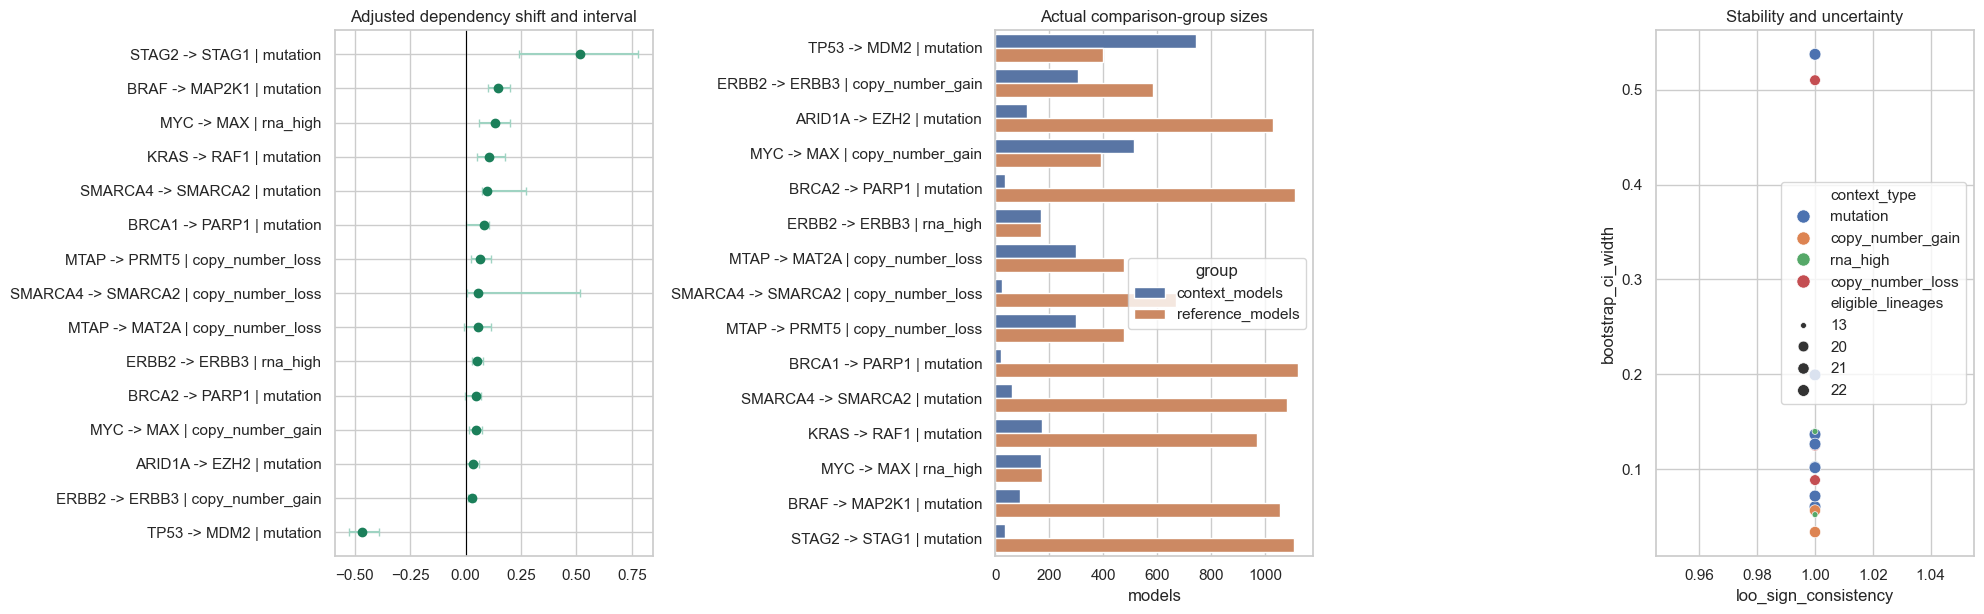

PASS: hypothesis grain, group-size, prevalence, QC, and stability checks are valid.


In [7]:
assert features['hypothesis_id'].is_unique
measured = features['route_state'].eq('measured')
assert features.loc[measured, 'context_models'].ge(MIN_CONTEXT_MODELS).all()
assert features.loc[measured, 'reference_models'].ge(MIN_REFERENCE_MODELS).all()
assert features.loc[measured, 'context_prevalence_in_comparison'].between(0, 1).all()
assert features['qc_passing_fraction'].dropna().between(0, 1).all()
assert features['loo_sign_consistency'].dropna().between(0, 1).all()

quality_view = features[[
    'hypothesis_id', 'route_state', 'dependency_shift_adjusted', 'dependency_rank_effect_adjusted',
    'context_models', 'reference_models', 'eligible_lineages', 'bootstrap_ci_low', 'bootstrap_ci_high',
    'loo_shift_min', 'loo_shift_max', 'loo_sign_consistency', 'fdr_bh',
    'common_essential_target', 'qc_passing_fraction', 'stability_review',
]].copy()
display(quality_view)

plot_data = features.loc[measured].sort_values('dependency_shift_adjusted').reset_index(drop=True)
fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(plot_data) * 0.42)))
axes[0].errorbar(
    plot_data['dependency_shift_adjusted'], np.arange(len(plot_data)),
    xerr=[plot_data['dependency_shift_adjusted'] - plot_data['bootstrap_ci_low'], plot_data['bootstrap_ci_high'] - plot_data['dependency_shift_adjusted']],
    fmt='o', color='#1b7f5a', ecolor='#9fd3c2', capsize=3,
)
axes[0].set_yticks(np.arange(len(plot_data)), plot_data['hypothesis_id'])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Adjusted dependency shift and interval')

group_sizes = plot_data.melt(id_vars='hypothesis_id', value_vars=['context_models', 'reference_models'], var_name='group', value_name='models')
sns.barplot(data=group_sizes, x='models', y='hypothesis_id', hue='group', order=plot_data['hypothesis_id'], ax=axes[1])
axes[1].set_title('Actual comparison-group sizes'); axes[1].set_ylabel('')

sns.scatterplot(data=plot_data, x='loo_sign_consistency', y='bootstrap_ci_width', hue='context_type', size='eligible_lineages', s=90, ax=axes[2])
axes[2].set_title('Stability and uncertainty')
plt.tight_layout(); plt.show()

print('PASS: hypothesis grain, group-size, prevalence, QC, and stability checks are valid.')

### What this means for the project

A large shift based on a small context group is less secure than the same shift reproduced across many models and lineages. A narrow interval and stable leave-one-lineage-out direction improve confidence in the measurement, but independent experimental or tumour evidence is still required before calling the pair valid.

## 6. Model-Level Example

The strongest measured positive shift is shown as a model-level distribution. Selecting it here is for explanation of the calculation, not for declaring it the best biological pair.

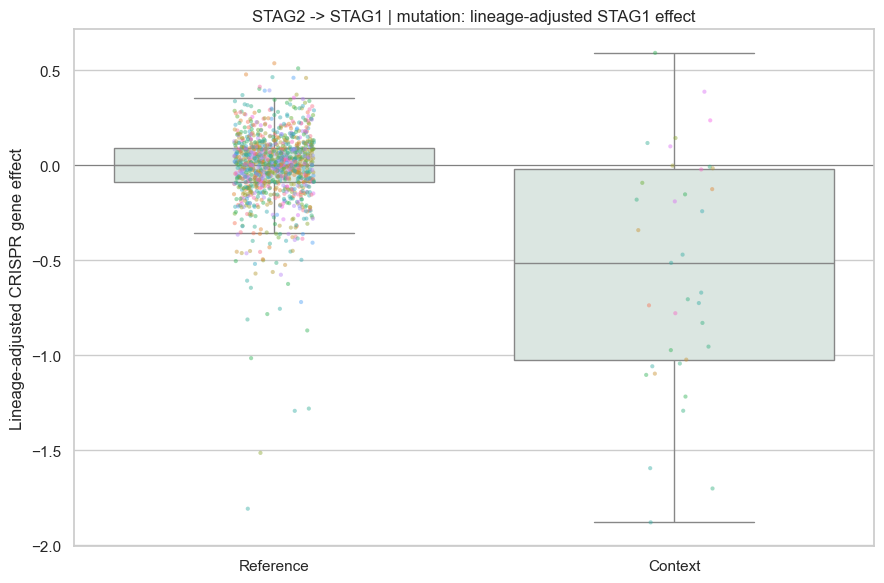

,value
hypothesis_id,STAG2 -> STAG1 | mutation
directional_pair_id,STAG2 -> STAG1
context_gene,STAG2
target_gene,STAG1
context_type,mutation
biological_reason,Cohesin paralog vulnerability hypothesis
context_definition,Damaging or driver-like event vs no such recor...
route_family,conditional_dependency
raw_context_models,37
raw_reference_models,1141


In [8]:
example = features.loc[measured].nlargest(1, 'dependency_shift_adjusted').iloc[0]
example_models = model_frames[example['hypothesis_id']]
plt.figure(figsize=(9, 6))
sns.boxplot(data=example_models, x='group', y='effect_adjusted', color='#d9e8e1', showfliers=False)
sns.stripplot(data=example_models, x='group', y='effect_adjusted', hue='oncotree_lineage', legend=False, alpha=0.45, size=3)
plt.axhline(0, color='grey', linewidth=0.8)
plt.title(f"{example['hypothesis_id']}: lineage-adjusted {example['target_gene']} effect")
plt.ylabel('Lineage-adjusted CRISPR gene effect'); plt.xlabel('')
plt.tight_layout(); plt.show()
display(example.to_frame('value'))

## 7. Export and Feature Manifest

The output retains all declared hypotheses, including insufficient or negative results. This prevents selective reporting and records why a feature is unavailable.

In [9]:
features.to_csv(PATHS['features'], index=False)
manifest = {
    'feature_table': str(PATHS['features'].relative_to(PROJECT_ROOT)),
    'grain': 'one row per declared directional pair and molecular-context definition',
    'route_family': 'conditional_dependency',
    'source_release': master['release'].dropna().iloc[0],
    'primary_feature': 'dependency_shift_adjusted',
    'positive_direction': 'positive means context models have more negative target-gene CRISPR effect than reference models',
    'input_files': [str(PATHS[name].relative_to(PROJECT_ROOT)) for name in ['model_master', 'gene_master', 'crispr_context', 'gene_effect', 'gene_dependency', 'mutations', 'copy_number', 'expression']],
    'declared_hypotheses': hypotheses.to_dict(orient='records'),
    'minimum_models_per_lineage': MIN_LINEAGE_MODELS,
    'minimum_context_models': MIN_CONTEXT_MODELS,
    'minimum_reference_models': MIN_REFERENCE_MODELS,
    'minimum_total_models': MIN_TOTAL_MODELS,
    'bootstrap_replicates': BOOTSTRAP_REPLICATES,
    'random_seed': RANDOM_SEED,
    'lineage_adjustment': 'subtract target-gene median within eligible selected models of each lineage',
    'missingness_rule': 'assay-missing models are excluded and insufficient hypotheses are retained without a zero effect',
    'confidence_context_only': ['group sizes', 'eligible lineages', 'bootstrap interval', 'leave-one-lineage-out stability', 'common-essential target', 'CRISPR QC'],
    'held_out_from_first_model': ['PRISM', 'TCGA', 'Reactome', 'STRING', 'BioGRID'],
    'row_count': int(len(features)),
}
PATHS['manifest'].write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'Wrote {len(features):,} directional feature rows to {PATHS["features"]}')
print(f'Wrote manifest to {PATHS["manifest"]}')

Wrote 16 directional feature rows to data\depmap_24Q4\architecture\feature_engineering\directional_conditional_dependency_features.csv
Wrote manifest to data\depmap_24Q4\architecture\feature_engineering\directional_conditional_dependency_manifest.json


## Decision Carried Forward

`dependency_shift_adjusted` and its rank-based companion are candidate conditional-dependency features. Context definition, group sizes, uncertainty, lineage stability, common-essential status, and QC remain visible. Mutation, CN loss, CN gain, and RNA-high rows are never collapsed into one generic alteration feature. Final feature admission requires the cross-feature audit and independent lineage-held-out validation.